In [48]:
# !pip install scikit-learn
# !pip install seaborn
# !pip install xgboost

# SOURCE: https://www.geeksforgeeks.org/machine-learning/building-your-first-machine-learning-model/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

import warnings

In [120]:

warnings.filterwarnings('ignore')

df = pd.read_csv("Task 3 and 4_Loan_Data.csv" )

# id_default_outstanding = df.loc[df["default"] == 0, "credit_lines_outstanding"]
# code
# counts = df['credit_lines_outstanding'].value_counts()

df.head()
# df.info()
# df.describe().T
# df.isnull().sum() # NO NULLS!
# df.hist(bins=20, figsize=(10, 10))
# plt.show()
# See the correlation between each column
# res = df.corr()
# print(res)


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


                          credit_lines_outstanding    income  years_employed  \
credit_lines_outstanding                  1.000000  0.022272       -0.087900   
income                                    0.022272  1.000000        0.001814   
years_employed                           -0.087900  0.001814        1.000000   
fico_score                               -0.258177 -0.010528        0.255873   
default                                   0.862815  0.016309       -0.284506   

                          fico_score   default  
credit_lines_outstanding   -0.258177  0.862815  
income                     -0.010528  0.016309  
years_employed              0.255873 -0.284506  
fico_score                  1.000000 -0.324515  
default                    -0.324515  1.000000  


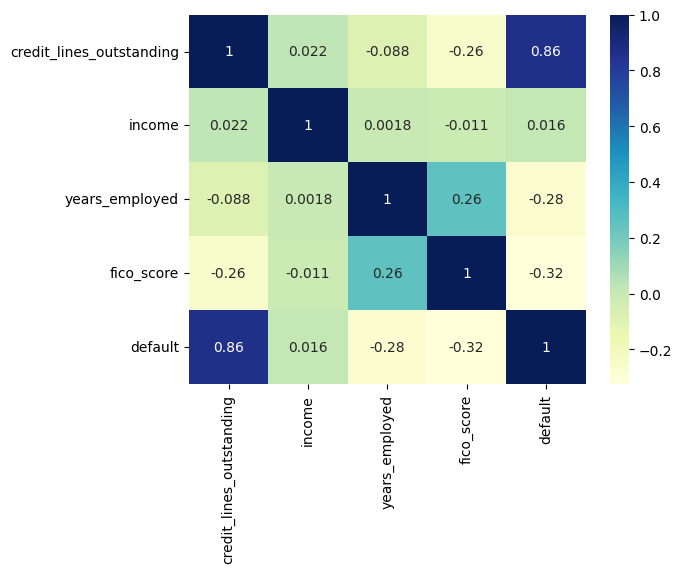

In [121]:

# Drop redundant features that will negatively effect the model's performance
df = df.drop(columns=['total_debt_outstanding', 'loan_amt_outstanding', 'customer_id'])
# Note: Keep credit_lines_outstanding as it is a more direct measure of the number of loans a borrower has, 
# which can be an important factor in assessing credit risk. Total_debt_outstanding and loan_amt_outstanding 
# may be correlated with credit_lines_outstanding, but they do not provide additional information about the 
# number of loans a borrower has, which is a key factor in determining their creditworthiness.

# Compute correlation matrix
co_mtx = df.corr(numeric_only=True)


# Print correlation matrix
print(co_mtx)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()


In [122]:
features = df.drop(['default'], axis=1)
target = df['default']

xtrain, xtest, ytrain, ytest = train_test_split(
    features, target, test_size=0.2, random_state=40)

xtrain.shape, xtest.shape

((8000, 4), (2000, 4))

In [123]:
# Normalize the data
norm = MinMaxScaler()
xtrain = norm.fit_transform(xtrain)
xtest = norm.transform(xtest)


In [124]:
# Data has been prepared, let's train the model.
models = [LogisticRegression(), XGBClassifier(), SVC(kernel='rbf', probability=True)]

for i in range(3):
    models[i].fit(xtrain, ytrain)

    print(f'{models[i]} : ')
    print('Training Accuracy : ', metrics.roc_auc_score(ytrain, models[i].predict(xtrain)))
    print('Validation Accuracy : ', metrics.roc_auc_score(
        ytest, models[i].predict(xtest)))
    print()

LogisticRegression() : 
Training Accuracy :  0.9852308450554135
Validation Accuracy :  0.9792857270748863

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  0.9999234068627452
Validation Accuracy :  0.9898398167846487

SVC(probability=True) : 
Training Accuracy :  

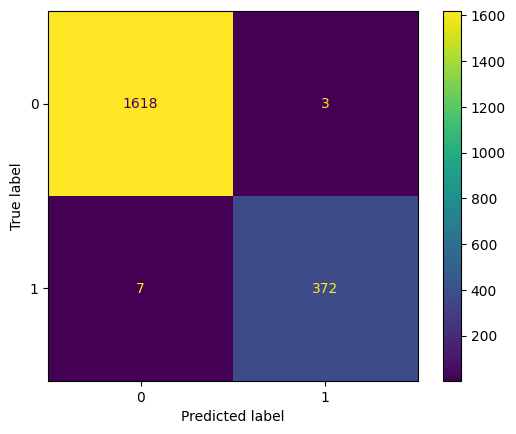

In [125]:
# Evaluate the models' performance
cm = confusion_matrix(ytest, models[1].predict(xtest))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=models[1].classes_)
disp.plot()

In [126]:
print(metrics.classification_report(ytest,
                                    models[1].predict(xtest)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1621
           1       0.99      0.98      0.99       379

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [170]:

# print(xtest)
# customer_id	credit_lines_outstanding	loan_amt_outstanding	total_debt_outstanding	income	     years_employed	fico_score	default
#  	8153374	    0	                        5221.545193	            3915.471226	            78039.38546	 5	             605	    0

# REMOVE: 'total_debt_outstanding', 'loan_amt_outstanding', 'customer_id'

# credit_lines_outstanding, income, years_employed, fico_score
# NO DEFAULT: 0, 78039.38546, 5, 605
# DEFAULT: 	5, 7442532, 1, 572
# predictions = models[2].predict([[0, 78039.38546, 5, 605]])
input_prediction = [[0, 76750.28031, 8, 6606]]
MODEL_NUM = 1
predictions = models[MODEL_NUM].predict(input_prediction)
class_probabilities = models[MODEL_NUM].predict_proba(input_prediction)

default = bool(predictions[0])
if default == True:
    print("Probability of Defaulting: " + str(class_probabilities[0][1]*100) + "%")
else:
    print("Probability of NOT Defaulting: " + str(class_probabilities[0][0]*100) + "%")

Probability of NOT Defaulting: 99.99879%
